In [5]:
# Instalar versión compatible
!pip install wfdb==3.4.1

In [33]:
# === LIBRERÍAS ===
import wfdb
import numpy as np
import pandas as pd
from scipy.stats import entropy, kurtosis, skew
import os
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.decomposition import FastICA
import matplotlib.pyplot as plt
import seaborn as sns
from joblib import Parallel, delayed

# === PARTE 1: Función de extracción de características por canal ===
def extract_features_emg(signal):
    feats = {
        "mean": np.mean(signal),
        "std": np.std(signal),
        "rms": np.sqrt(np.mean(signal**2)),
        "entropy": entropy(np.histogram(signal, bins=60)[0] + 1e-8),
        "skewness": skew(signal),
        "kurtosis": kurtosis(signal),
    }
    return feats

In [34]:
# === PARTE 2: Función para procesar cada archivo ===
def process_file(file_path, filename):
    record = wfdb.rdrecord(file_path)
    emg_data = record.p_signal

    file_features = []
    for channel_index, channel in enumerate(emg_data.T):
        feats = extract_features_emg(channel)
        feats['file'] = filename
        feats['channel'] = channel_index
        file_features.append(feats)
    
    return file_features

# === PARTE 3: Cargar los archivos EMG ===
folder = 'D:/Señales/Base/Sujeto1'  # Cambia la ruta de acuerdo a tu carpeta

# Lista de archivos a procesar
file_list = [f for f in os.listdir(folder) if f.endswith('.dat')]

# Procesamiento paralelo
results = Parallel(n_jobs=-1)(delayed(process_file)(os.path.join(folder, filename[:-4]), filename) for filename in file_list)

# Unir resultados
all_features = [item for sublist in results for item in sublist]
df = pd.DataFrame(all_features)

In [35]:
# Limpiar nombre de archivo y extraer el número de gesto
df["filename_clean"] = df["file"].str.replace(".dat", "", regex=False)
df["gesture_id"] = df["filename_clean"].apply(lambda x: str(int(x.split("_")[4])))  # Asegurarse de quitar ceros a la izquierda

# Mapeo de gestos
gesture_map = {
    "1": "Fist", "2": "Pinch", "3": "Flex Index", "4": "Flex Middle",
    "5": "Flex Ring", "6": "Flex Little", "7": "Open Hand", "8": "Thumb Up",
    "9": "Point", "10": "Peace", "11": "OK", "12": "Rock", "13": "Claw",
    "14": "Palm", "15": "Wrist Flexion", "16": "Wrist Extension",
    "17": "Rest", "18": "Grip", "19": "Release", "20": "Wave"
}

# Asignar nombre a cada gesto
df["gesture_name"] = df["gesture_id"].map(gesture_map).fillna(df["gesture_id"])

# Concatenar número y nombre del gesto
df["gesture_label"] = df["gesture_id"] + ": " + df["gesture_name"]

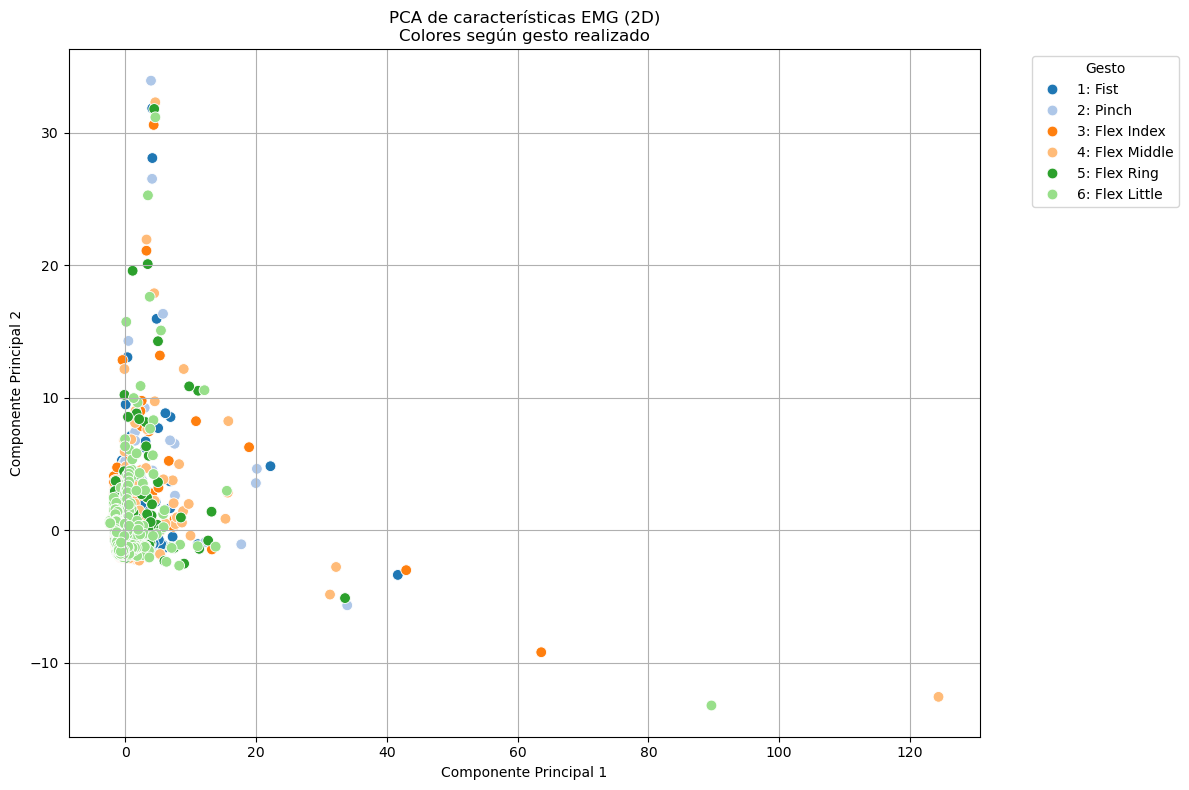

In [36]:
# === PARTE 4: PCA y visualización ===

# Selección de columnas numéricas
X_raw = df.select_dtypes(include=[np.number]).copy()

# Escalado robusto
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_raw)

# PCA a 2 dimensiones
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Crear DataFrame para la visualización
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["Gesto"] = df["gesture_label"]  # Utilizar la columna 'gesture_label' para los colores

# === GRAFICAR ===
plt.figure(figsize=(12, 8))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="Gesto", palette="tab20", s=60)
plt.title("PCA de características EMG (2D)\nColores según gesto realizado")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.legend(title="Gesto", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

In [41]:
# === PARTE 5: Clasificación de STC (por ahora, usaremos etiquetas simples) ===

# Suponiendo que las etiquetas para STC sean "0" para "Sano" (sin STC), las pondremos manualmente para este ejemplo.
df["label"] = 0  # Como solo tienes personas sanas, las etiquetas son 0.

# Eliminar las columnas no numéricas como "file", "gesture_name", "gesture_label", "filename_clean", "gesture_id"
X = df.drop(columns=["file", "gesture_name", "gesture_label", "filename_clean", "gesture_id", "label"])  # Las características

# Verificar que las características son numéricas
print(X.dtypes)

# Etiquetas de clasificación
y = df["label"]  # Etiquetas de STC

# Dividir los datos en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenamos el modelo RandomForest
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Realizamos predicciones
y_pred = clf.predict(X_test)

# Evaluamos el rendimiento
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


mean        float64
std         float64
rms         float64
entropy     float64
skewness    float64
kurtosis    float64
channel       int64
dtype: object
Accuracy: 1.0

Confusion Matrix:
 [[1076]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1076

    accuracy                           1.00      1076
   macro avg       1.00      1.00      1.00      1076
weighted avg       1.00      1.00      1.00      1076



d:\Code\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:409: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [ ]:
from sklearn.decomposition import FastICA
import matplotlib.pyplot as plt
import numpy as np

# === PARTE 6: Evaluación de MUAPs y reclutamiento reducido ===

def segment_signal(signal, window_size=100, overlap=50):
    """
    Divide la señal en ventanas deslizantes.
    """
    if len(signal) == 0:
        print("La señal está vacía, no se puede segmentar.")
        return np.array([])  # Retorna un array vacío si la señal está vacía
    
    segments = []
    for i in range(0, len(signal) - window_size, overlap):
        segment = signal[i:i + window_size]
        segments.append(segment)
    
    # Verificar si se generaron segmentos
    if len(segments) == 0:
        print("No se generaron segmentos. Revisa la longitud de la señal y los parámetros de segmentación.")
        return np.array([])  # Retorna un array vacío si no se generaron segmentos
    
    return np.array(segments)

# Ejemplo de segmentación de la señal de un canal específico (canal 0)
# Asegúrate de que el canal seleccionado tiene datos válidos
signal_data = df.iloc[0, :-3].to_numpy()  # Primer canal, excluyendo columnas no numéricas

# Verificar la longitud de la señal
print(f"Longitud de la señal: {len(signal_data)}")

# Asegúrate de que la señal tiene suficiente longitud para aplicar segmentación
if len(signal_data) < 100:
    print("La señal es demasiado corta para segmentarla con un tamaño de ventana de 100.")
else:
    segments = segment_signal(signal_data)  # Segmentamos la señal

    if len(segments) > 0:
        # Asegurarse de que los segmentos son 2D
        print("Forma de los segmentos:", segments.shape)

        # Asegurarse de que los segmentos son 2D, y si no lo son, cambiar la forma
        segments_2d = segments.reshape(segments.shape[0], -1)  # Aseguramos que tenga 2 dimensiones

        # Aplicar ICA a los segmentos de la señal
        def extract_muaps(segments_2d):
            """
            Aplica ICA para separar las componentes de la señal EMG (MUAPs).
            """
            ica = FastICA(n_components=3)
            muaps = ica.fit_transform(segments_2d)  # Obtiene los componentes (MUAPs)
            return muaps

        muaps = extract_muaps(segments_2d)

        # Graficar los resultados de los MUAPs extraídos
        plt.figure(figsize=(10, 6))
        plt.plot(muaps)
        plt.title("MUAPs extraídos de la señal EMG")
        plt.xlabel("Muestras")
        plt.ylabel("Amplitud")
        plt.show()
    else:
        print("No se generaron segmentos válidos.")


Longitud de la señal: 10
La señal es demasiado corta para segmentarla con un tamaño de ventana de 100.


Distribución de clases en y_train: label
0    4300
Name: count, dtype: int64
Error: El modelo solo tiene una clase.
Probabilidades predichas (para la clase 'STC'): [1. 1. 1. ... 1. 1. 1.]


d:\Code\Anaconda\Lib\site-packages\sklearn\metrics\_ranking.py:1183: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


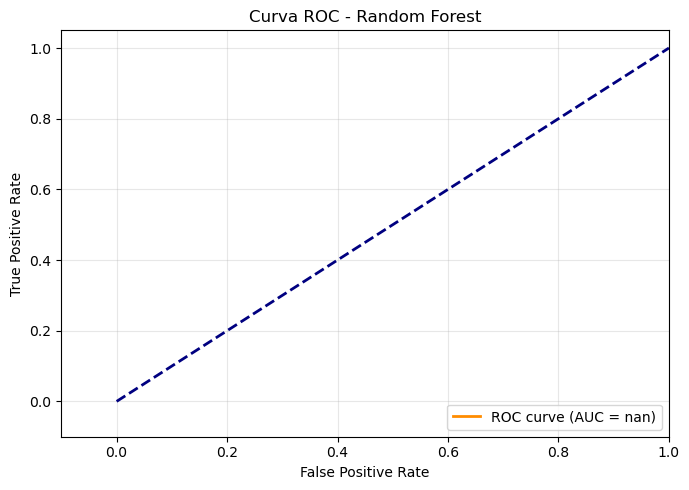

In [54]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import LabelBinarizer
import matplotlib.pyplot as plt

# === Clasificación (ya realizada en tu código) ===

# Realizamos predicciones
y_pred = clf.predict(X_test)

# Verificar la distribución de clases en y_train
print("Distribución de clases en y_train:", y_train.value_counts())

# === Curva ROC y AUC ===
# Binarizar las etiquetas para clasificación binaria
lb = LabelBinarizer()
y_test_bin = lb.fit_transform(y_test)

# Verifica que las probabilidades de predicción están en el formato adecuado
if clf.classes_.shape[0] > 1:  # Verifica que haya más de una clase
    y_pred_prob = clf.predict_proba(X_test)[:, 1]  # Probabilidad para la clase 'Sano' o 'STC'
else:
    print("Error: El modelo solo tiene una clase.")
    y_pred_prob = clf.predict_proba(X_test)[:, 0]  # Esto manejaría el caso cuando solo hay una clase (poco probable)

# Verifica las probabilidades
print("Probabilidades predichas (para la clase 'STC'):", y_pred_prob)

# Calcular curva ROC y AUC
fpr, tpr, thresholds = roc_curve(y_test_bin, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Graficar curva ROC
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([-0.1, 1.0])
plt.ylim([-0.1, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - Random Forest')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
